# ETL com Python - Acompanhamento de Pacientes com Condições Crônicas

Projeto desenvolvido durante o Bootcamp TOTVS - Fundamentos de Engenharia de Dados e Machine Learning.

Objetivo: demonstrar um pipeline ETL utilizando Python para gerar mensagens personalizadas para pacientes com condições crônicas.

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

In [74]:
pacientes = [
    {
        "id": 1,
        "nome": "Maria Silva",
        "idade": 67,
        "sexo": "F",
        "condicao_principal": "Diabetes",
        "comorbidades": "Hipertensão",
        "ultima_consulta": "2025-12-10"
    },
    {
        "id": 2,
        "nome": "João Santos",
        "idade": 72,
        "sexo": "M",
        "condicao_principal": "Hipertensão",
        "comorbidades": "Obesidade",
        "ultima_consulta": "2025-11-20"
    },
    {
        "id": 3,
        "nome": "Ana Costa",
        "idade": 58,
        "sexo": "F",
        "condicao_principal": "Obesidade",
        "comorbidades": "Diabetes",
        "ultima_consulta": "2025-10-15"
    },
    {
        "id": 4,
        "nome": "Carlos Oliveira",
        "idade": 64,
        "sexo": "M",
        "condicao_principal": "Diabetes",
        "comorbidades": "Hipertensão e Obesidade",
        "ultima_consulta": "2025-09-05"
    },
    {
        "id": 5,
        "nome": "Patrícia Souza",
        "idade": 49,
        "sexo": "F",
        "condicao_principal": "Hipertensão",
        "comorbidades": "Dislipidemia",
        "ultima_consulta": "2025-08-18"
    },
    {
        "id": 6,
        "nome": "Roberto Lima",
        "idade": 75,
        "sexo": "M",
        "condicao_principal": "Doença Cardiovascular",
        "comorbidades": "Diabetes e Hipertensão",
        "ultima_consulta": "2025-12-01"
    },
    {
        "id": 7,
        "nome": "Fernanda Alves",
        "idade": 53,
        "sexo": "F",
        "condicao_principal": "Diabetes",
        "comorbidades": "Doença Renal Crônica",
        "ultima_consulta": "2025-11-07"
    },
    {
        "id": 8,
        "nome": "Marcelo Pereira",
        "idade": 61,
        "sexo": "M",
        "condicao_principal": "Hipertensão",
        "comorbidades": "Tabagismo",
        "ultima_consulta": "2025-10-28"
    },
    {
        "id": 9,
        "nome": "Juliana Martins",
        "idade": 45,
        "sexo": "F",
        "condicao_principal": "Obesidade",
        "comorbidades": "Hipertensão",
        "ultima_consulta": "2025-12-15"
    },
    {
        "id": 10,
        "nome": "Paulo Henrique",
        "idade": 69,
        "sexo": "M",
        "condicao_principal": "Diabetes",
        "comorbidades": "Hipertensão e Dislipidemia",
        "ultima_consulta": "2025-11-30"
    }
]

df = pd.DataFrame(pacientes)

df.head()

,id,nome,idade,sexo,condicao_principal,comorbidades,ultima_consulta
0,1,Maria Silva,67,F,Diabetes,Hipertensão,2025-12-10
1,2,João Santos,72,M,Hipertensão,Obesidade,2025-11-20
2,3,Ana Costa,58,F,Obesidade,Diabetes,2025-10-15
3,4,Carlos Oliveira,64,M,Diabetes,Hipertensão e Obesidade,2025-09-05
4,5,Patrícia Souza,49,F,Hipertensão,Dislipidemia,2025-08-18


In [113]:
df["proxima_consulta_data"] = pd.to_datetime(
    df["proxima_consulta"],
    format="%d/%m/%Y"
)

df.sort_values(
    "proxima_consulta_data"
)[
    ["nome","proxima_consulta"]
]

,nome,proxima_consulta
4,Patrícia Souza,18/02/2026
3,Carlos Oliveira,05/03/2026
2,Ana Costa,15/04/2026
7,Marcelo Pereira,28/04/2026
6,Fernanda Alves,07/05/2026
1,João Santos,20/05/2026
9,Paulo Henrique,30/05/2026
5,Roberto Lima,01/06/2026
0,Maria Silva,10/06/2026
8,Juliana Martins,15/06/2026


In [114]:
df["mensagem"] = df.apply(
    lambda linha: gerar_mensagem(
        linha["nome"],
        linha["idade"],
        linha["condicao_principal"],
        linha["comorbidades"],
        linha["proxima_consulta"]
    ),
    axis=1
)

In [115]:
def gerar_mensagem(
    nome,
    idade,
    condicao,
    comorbidades,
    proxima_consulta
):

    return (
        f"Olá {nome}! Aos {idade} anos, manter o acompanhamento da "
        f"{condicao} e das comorbidades ({comorbidades}) é fundamental "
        f"para sua saúde. Sua próxima consulta está prevista para "
        f"{proxima_consulta}."
    )

In [119]:
df[
    [
        "nome",
        "condicao_principal",
        "proxima_consulta",
        "mensagem"
    ]
]

,nome,condicao_principal,proxima_consulta,mensagem
0,Maria Silva,Diabetes,10/06/2026,"Olá Maria Silva! Aos 67 anos, manter o acompan..."
1,João Santos,Hipertensão,20/05/2026,"Olá João Santos! Aos 72 anos, manter o acompan..."
2,Ana Costa,Obesidade,15/04/2026,"Olá Ana Costa! Aos 58 anos, manter o acompanha..."
3,Carlos Oliveira,Diabetes,05/03/2026,"Olá Carlos Oliveira! Aos 64 anos, manter o aco..."
4,Patrícia Souza,Hipertensão,18/02/2026,"Olá Patrícia Souza! Aos 49 anos, manter o acom..."
5,Roberto Lima,Doença Cardiovascular,01/06/2026,"Olá Roberto Lima! Aos 75 anos, manter o acompa..."
6,Fernanda Alves,Diabetes,07/05/2026,"Olá Fernanda Alves! Aos 53 anos, manter o acom..."
7,Marcelo Pereira,Hipertensão,28/04/2026,"Olá Marcelo Pereira! Aos 61 anos, manter o aco..."
8,Juliana Martins,Obesidade,15/06/2026,"Olá Juliana Martins! Aos 45 anos, manter o aco..."
9,Paulo Henrique,Diabetes,30/05/2026,"Olá Paulo Henrique! Aos 69 anos, manter o acom..."


In [120]:
# Converter a coluna para data
df["proxima_consulta_data"] = pd.to_datetime(
    df["proxima_consulta"],
    format="%d/%m/%Y"
)

# Ordenar pela próxima consulta
df = df.sort_values(
    by="proxima_consulta_data"
)

# Remover coluna auxiliar (opcional)
df = df.drop(columns=["proxima_consulta_data"])

In [121]:
df.to_csv(
    "pacientes_com_mensagens.csv",
    index=False
)

print("Arquivo exportado com sucesso!")

Arquivo exportado com sucesso!


In [122]:
from google.colab import files

files.download(
    "pacientes_com_mensagens.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Indicadores

In [105]:
print(f"Total de pacientes: {len(df)}")

print(f"Média de idade: {df['idade'].mean():.1f} anos")

print(f"Total de mulheres: {(df['sexo']=='F').sum()}")

print(f"Total de homens: {(df['sexo']=='M').sum()}")

Total de pacientes: 10
Média de idade: 61.3 anos
Total de mulheres: 5
Total de homens: 5


In [78]:
df["sexo"].value_counts()

,count
sexo,
F,5
M,5


In [79]:
df["idade"].mean()

np.float64(61.3)

In [80]:
df["condicao_principal"].value_counts()

,count
condicao_principal,
Diabetes,4
Hipertensão,3
Obesidade,2
Doença Cardiovascular,1


<Axes: xlabel='condicao_principal'>

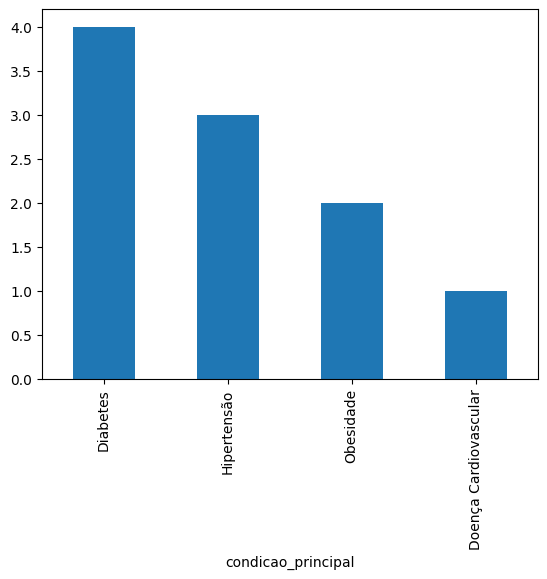

In [97]:
df["condicao_principal"].value_counts().plot.bar()

In [98]:
pd.crosstab(
    df["sexo"],
    df["condicao_principal"]
)

condicao_principal,Diabetes,Doença Cardiovascular,Hipertensão,Obesidade
sexo,,,,
F,2,0,1,2
M,2,1,2,0


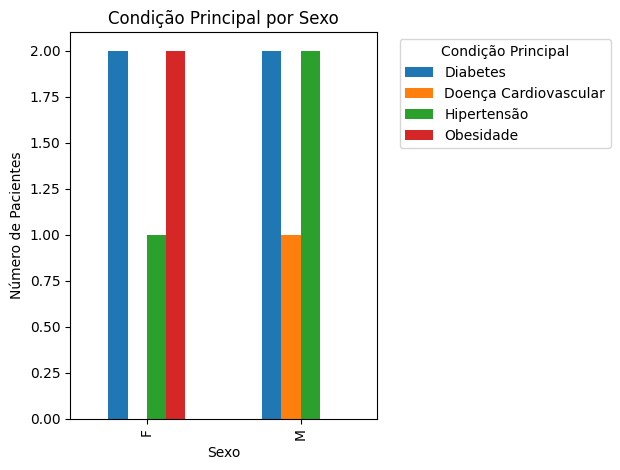

In [99]:
import matplotlib.pyplot as plt

pd.crosstab(
    df["sexo"],
    df["condicao_principal"]
).plot(kind="bar")

plt.title("Condição Principal por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de Pacientes")

plt.legend(
    title="Condição Principal",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [101]:
df["faixa_etaria"] = pd.cut(
    df["idade"],
    bins=[0, 39, 59, 79, 120],
    labels=[
        "18-39",
        "40-59",
        "60-79",
        "80+"
    ]
)

df[["idade", "faixa_etaria"]].head()

,idade,faixa_etaria
0,67,60-79
1,72,60-79
2,58,40-59
3,64,60-79
4,49,40-59


In [102]:
pd.crosstab(
    df["faixa_etaria"],
    df["condicao_principal"]
)

condicao_principal,Diabetes,Doença Cardiovascular,Hipertensão,Obesidade
faixa_etaria,,,,
40-59,1,0,1,2
60-79,3,1,2,0


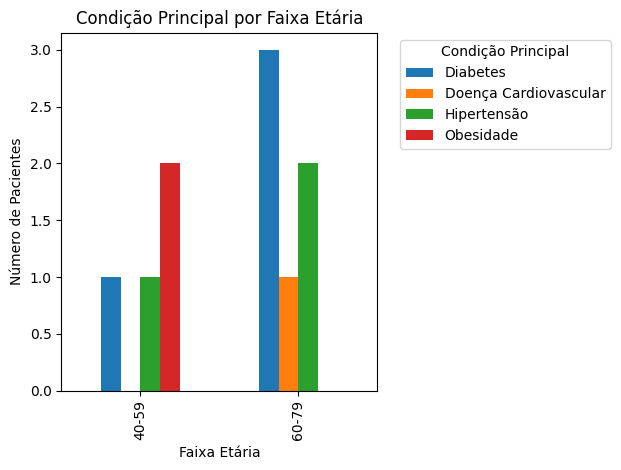

In [103]:
pd.crosstab(
    df["faixa_etaria"],
    df["condicao_principal"]
).plot(kind="bar")

plt.title(
    "Condição Principal por Faixa Etária"
)

plt.xlabel("Faixa Etária")
plt.ylabel("Número de Pacientes")

plt.legend(
    title="Condição Principal",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# Conclusões

- Foram analisados 10 pacientes com condições crônicas.
- Diabetes e Hipertensão foram as condições mais frequentes.
- A maior parte dos pacientes encontra-se na faixa etária de 60 a 79 anos.
- Foi implementada uma regra automática para cálculo da próxima consulta.
- O pipeline ETL permitiu automatizar a geração de mensagens de acompanhamento para os pacientes.